### 📚 Lab Task 2: Cleaning Up the Mess

You’ll be working with a dataset of real student grades — 7 assignments and a final exam — but things aren’t as clean as they should be. Some values are missing, some are way off, and it’s your job to fix it.

You’ll explore the data, figure out what went wrong, and try different strategies to clean it up.

Get ready to:
- Spot broken data
- Try out different fixes
- Compare models
- Justify your decisions

### Dataset Introduction

The dataset comes from real student grades in a course at SFU. Students completed **7 assignments**, and we also have their **final exam grade**.

It’s your job to explore the dataset and clean it up.

---

> 💡 **Note**: Students could receive bonus marks for some assignments:
> - **A2**: up to **15** points
> - **A4**: up to **5** points
> - **A6**: up to **10** points  
> Keep this in mind when you're evaluating high or unusual scores — they might not be errors!


**Attention:** The bonus values are in **points** not **percentages**!!!
---

### ✅ What You Need to Do

**1) Explore the dataset**
  - Look at basic stats, column names, and what the data looks like
  - Identify anything that stands out right away

**2) Check the correlations**
  - Use a correlation matrix to find relationships between assignments and the final exam
  - Do any assignments seem strongly related to final exam performance?

-  **If you could only use two assignment grades to predict the final exam**, which ones would you choose — and why?

**3) Check for missing values**
  - Which columns have them?
  - How many are missing?

**4) Handle the missing values**
  - Try out different imputation strategies (mean, median, remove, etc.)
  - Which one gives you the best results? Why do you think that is?
  - Exploration idea: search and see what are the ways of evaluating your results. How can you make sure that a strategy for handling the missing values works better than the other?

**5) Check for outliers**
  - Identify values that seem unrealistic or suspicious
  - Decide whether to keep, modify, or remove them — and explain your reasoning
  - Compare the results

---

For each step, be ready to explain your decisions. There isn’t always one "right" answer — we’re more interested in your reasoning!

> 💡 **Note**: If handling missing values and outliers for **all 7 assignments** feels overwhelming, it’s totally fine to **focus on just the two columns you think are most important**.  
> Just make sure your reasoning for choosing them is solid and clearly explained.


# 1) Explore the Dataset

In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("grades_crpt.csv")

In [2]:
df.dtypes

A1            float64
A2            float64
A3            float64
A4            float64
A5            float64
A6            float64
A7            float64
Final_Exam    float64
user_id           str
dtype: object

In [3]:
df

,A1,A2,A3,A4,A5,A6,A7,Final_Exam,user_id
0,NaN,NaN,30.0,75.0,90.0,65.0,50.6,68.8,U001
1,100.0,NaN,NaN,92.5,100.0,100.0,84.4,50.3,U002
2,75.0,69.6,NaN,86.2,100.0,NaN,NaN,67.8,U003
3,25.0,78.6,40.0,0.0,50.0,30.7,0.0,0.0,U004
4,0.0,NaN,0.0,0.0,NaN,NaN,NaN,0.0,U005
...,...,...,...,...,...,...,...,...,...
81,NaN,NaN,NaN,56.2,NaN,29.2,60.0,57.5,U082
82,87.5,-30.6,70.0,174.8,91.0,NaN,146.4,64.1,U083
83,79.2,NaN,60.0,27.5,50.0,60.0,75.0,45.6,U084
84,NaN,0.0,85.0,100.0,55.0,0.0,0.0,30.6,U085


The dataset is loaded using pd.read_csv() and stored as a pandas DataFrame so it can be inspected and cleaned. I used df.dtypes to check the data type of each column, which helps confirm whether the assignment and exam columns are being treated as numeric values. I also displayed the full DataFrame to get an initial look at the rows, columns, and possible unusual values.

In [4]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


The mean for the final exam is a significantly lower than the means for the assignments, yet, it also has a lower standard deviation. I also observe that there are negative score values, which is possible inaccurate and meant to be positive.

# 2) Check the Correlations

In [5]:
import matplotlib.pyplot as plt

### Correlation Matrix

In [6]:
import seaborn as sns

numeric_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'Final_Exam']
corr_matrix = df[numeric_cols].corr()

print(corr_matrix.round(2))

              A1    A2    A3    A4    A5    A6    A7  Final_Exam
A1          1.00 -0.14  0.36  0.30  0.24  0.23 -0.02        0.21
A2         -0.14  1.00  0.21 -0.03  0.01  0.36  0.03        0.28
A3          0.36  0.21  1.00  0.19  0.19 -0.03  0.15        0.28
A4          0.30 -0.03  0.19  1.00  0.04  0.15  0.22        0.40
A5          0.24  0.01  0.19  0.04  1.00  0.24  0.03        0.02
A6          0.23  0.36 -0.03  0.15  0.24  1.00  0.15        0.25
A7         -0.02  0.03  0.15  0.22  0.03  0.15  1.00        0.38
Final_Exam  0.21  0.28  0.28  0.40  0.02  0.25  0.38        1.00


The numeric_cols list is used to select only the assignment and final exam columns. This avoids including non-numeric identifier columns such as user_id in the correlation calculation.

The code:

`corr_matrix = df[numeric_cols].corr()`

creates a correlation matrix showing how strongly each assignment score is related to the other assignment scores and the final exam score. Correlation values closer to 1 suggest a stronger positive relationship, while values closer to 0 suggest a weaker relationship.

### Heat Map

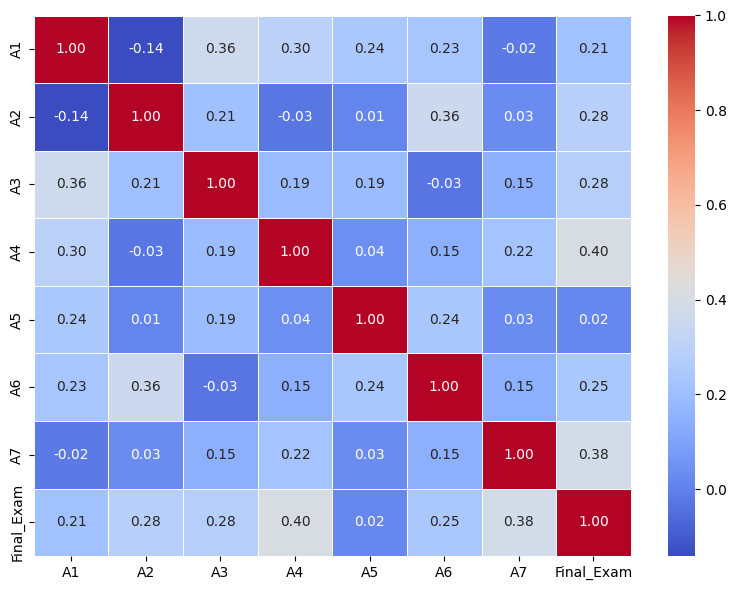

In [7]:
plt.figure(figsize=(8,6 ))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.tight_layout()
plt.show()

The heatmap visualizes the correlation matrix using colour intensity. This makes it easier to quickly identify which assignments have stronger relationships with the final exam. Based on the correlation results, A4 and A7 appear to have the strongest relationships with Final_Exam, so they would be better candidates for predicting final exam performance compared to the other assignments.

# 3) Check for Missing Values

In [8]:
print("user_id - Total Missing Values:", df["user_id"].isna().sum())
for col in numeric_cols:
    print(f"{col} - Total Missing Values: {df[col].isna().sum()}")

user_id - Total Missing Values: 0
A1 - Total Missing Values: 29
A2 - Total Missing Values: 25
A3 - Total Missing Values: 24
A4 - Total Missing Values: 9
A5 - Total Missing Values: 25
A6 - Total Missing Values: 19
A7 - Total Missing Values: 10
Final_Exam - Total Missing Values: 0


The code checks each column for missing values using `.isna().sum()`. The `.isna()` part returns whether each value is missing, and `.sum()` counts how many missing values exist in that column. The loop goes through every numeric grade column and prints the number of missing values for each one. This is useful because missing values can affect summary statistics, visualizations, and model training. Since the final exam column has no missing values but the assignment columns do, the missing data problem mainly affects the assignment scores.

In summary, all assignments feature some missing values, with the number of missing values shown above. There are no missing values for Final Exams.

# 4) Handle Missing Values

I tested three strategies for dealing with missing values: replacing missing values with the mean, replacing them with the median, and removing rows that contain missing values.

## Strategy: Mean

In [9]:
mean_df = df.copy()
for col in numeric_cols:
    mean_df[col] = mean_df[col].fillna(mean_df[col].mean())

In [10]:
mean_df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,27.829632,23.992445,35.870997,36.973973,21.433111,27.472004,24.809808,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,83.300000,78.600000,64.500000,75.675000,89.645902,70.000000,72.500000,45.850000
50%,83.671930,81.096721,68.174194,85.600000,89.822951,74.437313,78.465132,56.050000
75%,91.700000,92.900000,87.250000,95.000000,100.000000,89.500000,87.025000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


For the mean strategy, each missing value is replaced with the average score for that column:

`mean_df[col] = mean_df[col].fillna(mean_df[col].mean())`

## Strategy: Median

In [11]:
median_df = df.copy()
for col in numeric_cols:
    median_df[col] = median_df[col].fillna(median_df[col].median())

In [12]:
median_df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,84.962791,84.004651,71.474419,82.873256,91.202326,75.666279,78.347674,55.509302
std,27.889104,24.423614,36.265628,37.008191,21.572171,27.569905,24.817132,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,83.300000,78.600000,64.500000,75.675000,90.000000,70.000000,72.500000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,91.700000,92.900000,87.250000,95.000000,100.000000,89.500000,87.025000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


For the median strategy, each missing value is replaced with the middle value of that column:

`median_df[col] = median_df[col].fillna median_df[col].median()`

The median is often better when the dataset contains extreme values or outliers because it is less affected by unusually low or unusually high scores than the mean.

## Strategy: Remove

In [13]:
remove_df = df.copy()
remove_df = remove_df.dropna()

In [14]:
remove_df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,79.930769,80.223077,57.061538,78.838462,79.976923,65.484615,63.800000,52.230769
std,25.731316,18.100145,53.452230,59.102320,27.066712,33.277366,33.562827,23.014719
min,25.000000,57.100000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.000000,64.300000,40.000000,37.500000,80.000000,60.000000,68.800000,38.100000
50%,83.300000,78.600000,63.000000,88.800000,90.000000,72.000000,77.500000,54.400000
75%,91.700000,100.000000,83.000000,95.700000,97.000000,88.000000,81.200000,67.500000
max,129.900000,100.000000,152.200000,183.100000,100.000000,100.000000,112.300000,81.200000


For the removal strategy, `dropna()` removes every row that has at least one missing value. This creates a smaller dataset with no missing values, but it removes a large amount of data. In this case, removing rows reduces the dataset from 86 rows to only 13 rows, so this strategy loses too much useful information.

## Summary

Removing rows with missing values is the weakest option here because it reduces the dataset from 86 rows to only 13 rows, meaning most of the available data would be discarded. Median imputation is more appropriate because it preserves the dataset size while being less sensitive to extreme values than mean imputation.

# 5) Check for Outliers

I will identify outliers by visualizing them on histogram as suggested by Skiena (2017). I already observe via a sanity check that there are negative values at the minimum values and maximum values that surpass 100 (assumed percentage). However, this could be explained by penalties (resulting in excess negative marks) or bonus points (for completing additional tasks). Given the assignment instructions, I observe there are eligible bonuses for A2, A4, and A6. There are no bonuses for other assignments. Moreover, there are no remarks regarding penalties, so I will assume no penalties exist. The histogram section creates a 2-by-4 grid of plots, with one histogram for each assignment and the final exam. This helps show the distribution of scores and makes unusual values easier to notice visually.

<Axes: xlabel='Final_Exam', ylabel='Count'>

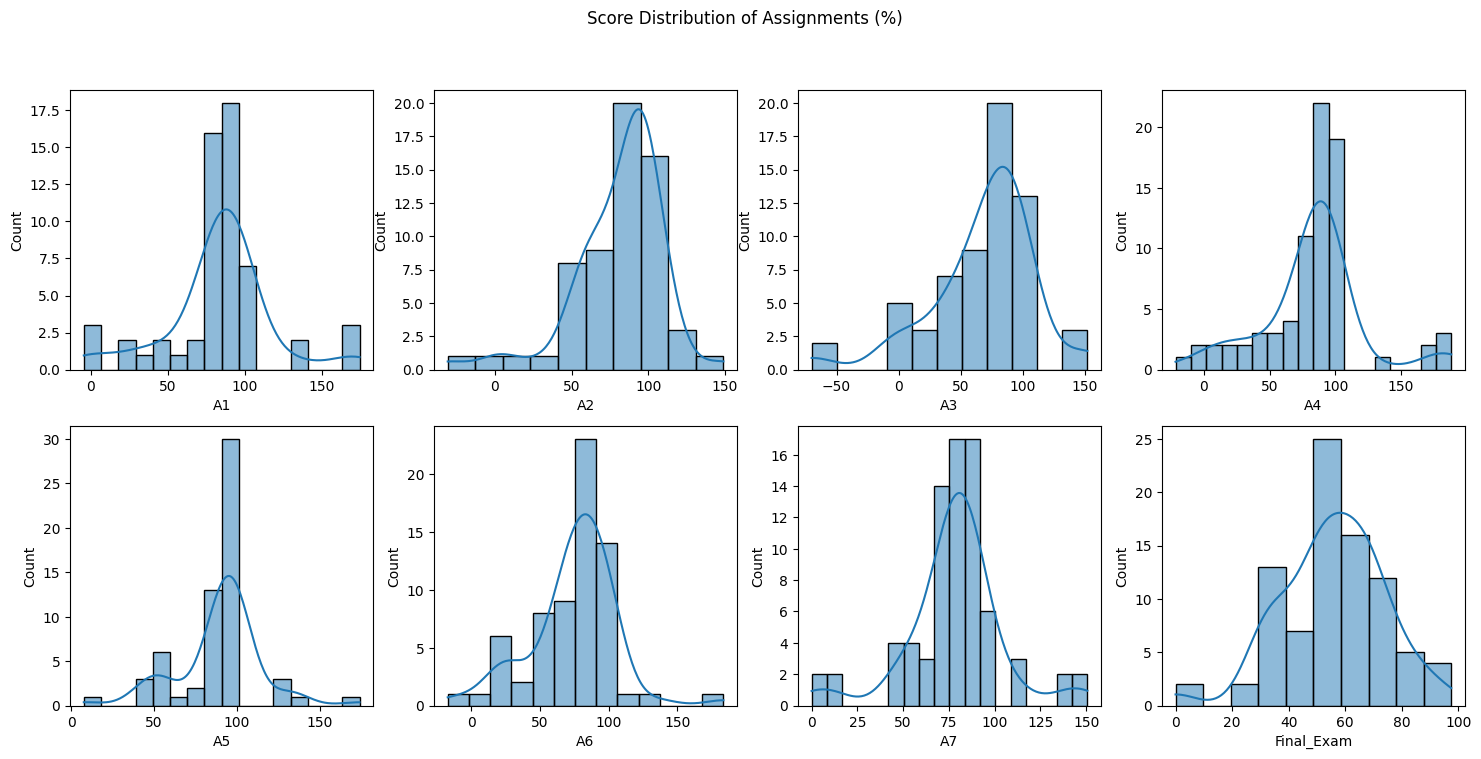

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

fig.suptitle('Score Distribution of Assignments (%)')
sns.histplot(ax=axes[0, 0], data=df, x='A1', kde=True)
sns.histplot(ax=axes[0, 1], data=df, x='A2', kde=True)
sns.histplot(ax=axes[0, 2], data=df, x='A3', kde=True)
sns.histplot(ax=axes[0, 3], data=df, x='A4', kde=True)
sns.histplot(ax=axes[1, 0], data=df, x='A5', kde=True)
sns.histplot(ax=axes[1, 1], data=df, x='A6', kde=True)
sns.histplot(ax=axes[1, 2], data=df, x='A7', kde=True)
sns.histplot(ax=axes[1, 3], data=df, x='Final_Exam', kde=True)

The code:

`fig, axes = plt.subplots(2, 4, figsize=(18, 8))`

creates the grid of plots. Each `sns.histplot()` call places one grade column into a specific position in that grid. The kde=True option adds a smooth curve over the histogram to make the overall shape of the distribution easier to see. The histograms and summary statistics show two main outlier issues: negative values and values above the reasonable maximum score. Since grades should not normally be negative, negative values are treated as data entry errors. Since most assignments are out of 100, scores above 100 are treated as invalid unless the assignment allows bonus points.

## Rationale

For the sake of the exercise, I will assume negative values were incorrectly inputted--instead, they should be positive. Moreover, I will also assume that values exceeding 100 are incorrect (for illegible assignments), and will limit them to 100. Moving forward, I will use the median as the base dataframe for cleaning. Lastly, I am unsure of what the points are worth in relation to the percentage for bonus eligible assignments. Therefore, I will assume that the maxmium values are the correct maximums when including bonuses.

## 5a) Clean Negative Numbers

For cleaning negative values, the code uses np.where() to check each value in a column. If the value is below 0, it replaces the value. Otherwise, it keeps the original value. A safer approach is to cap negative values at 0, because this avoids assuming that a negative value was simply missing a positive sign.

In [16]:
cleaned = median_df.copy()

# Drop replace negative values with positive inverts
for col in numeric_cols:
    cleaned[col] = np.where(cleaned[col] < 0, cleaned[col] * -1, cleaned[col])

## 5b) Clean Maximum Numbers (Exceed 100)

For cleaning high values, the maximum valid score should depend on whether the assignment allows bonus points. The regular assignments and final exam should be capped at 100. The bonus assignments should have higher maximums based on the lab instructions. As mentioned earlier, I will assume the maximum values are the correct ones. It's worth noting that only assignments A2, A4, and A6 have bonus marks, the rest do not.

In [17]:
# Clamp maximum number for assignments that don't have bonus points
bonus = ["A2", "A4", "A6"]
for col in numeric_cols:
    if col not in bonus:
        cleaned[col] = np.where(cleaned[col] > 100, 100, cleaned[col])

### Compare Raw vs Cleaned

The final comparison uses describe() on both the raw dataset and the cleaned dataset. This allows me to compare the summary statistics before and after cleaning.

#### Raw Dataset

In [18]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,57.000000,61.000000,62.000000,77.000000,61.000000,67.000000,76.000000,86.000000
mean,83.671930,81.096721,68.174194,82.332468,89.645902,74.437313,78.130263,55.509302
std,34.286481,28.556721,42.343621,39.101984,25.510505,31.176535,26.412058,18.176777
min,-4.500000,-30.600000,-70.100000,-21.600000,7.700000,-17.000000,0.000000,0.000000
25%,75.800000,64.300000,50.000000,72.000000,87.000000,60.000000,70.300000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,95.800000,100.000000,93.250000,95.000000,100.000000,92.500000,87.500000,67.725000
max,174.600000,148.900000,152.200000,188.200000,173.900000,183.600000,150.600000,97.500000


#### Cleaned Dataset

In [19]:
cleaned.describe()

,A1,A2,A3,A4,A5,A6,A7,Final_Exam
count,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,81.902326,84.716279,73.109302,83.375581,88.847674,76.061628,75.916279,55.509302
std,21.366714,21.795271,25.040450,35.848468,17.461768,26.446333,20.167614,18.176777
min,0.000000,0.000000,0.000000,0.000000,7.700000,0.000000,0.000000,0.000000
25%,83.300000,78.600000,69.075000,75.675000,90.000000,70.000000,72.500000,45.850000
50%,87.500000,91.100000,80.000000,87.500000,95.000000,80.000000,80.000000,56.050000
75%,91.700000,92.900000,87.250000,95.000000,100.000000,89.500000,87.025000,67.725000
max,100.000000,148.900000,100.000000,188.200000,100.000000,183.600000,100.000000,97.500000


## Assumption / Prediction
The cleaned dataset should have no missing values because median imputation was used. It should also have more realistic minimum and maximum values because negative scores and impossible high scores were corrected. The standard deviation should generally become smaller after cleaning because extreme values have less influence on the dataset.

## Reflection
After cleaning, the dataset has no missing values and the impossible score ranges have been addressed. I used median imputation because it preserves all 86 students while being more robust to extreme values than mean imputation. I capped scores based on the assignment rules: non-bonus assignments and the final exam were capped at 100, while A2, A4, and A6 were capped at their respective maximums because those assignments allowed bonus points. This produces a cleaner dataset while still respecting the grading rules described in the assignment.